# 🚀 完整DMPC框架: Flow Matching + CBF实时避障轨迹规划

## 系统架构

```
┌─────────────────────────────────────────────────────────────┐
│                    DMPC Planning Framework                   │
├─────────────────────────────────────────────────────────────┤
│                                                               │
│  1️⃣ 离线训练阶段 (Flow Matching)                             │
│     ├─ 生成Bezier训练数据                                    │
│     ├─ 训练1D UNet模型                                       │
│     └─ 学习平滑轨迹分布                                      │
│                                                               │
│  2️⃣ 在线规划阶段 (DMPC + CBF)                                │
│     ├─ Flow Matching生成候选轨迹                             │
│     ├─ CBF QP优化每一步控制                                  │
│     ├─ 实时避障和轨迹修正                                    │
│     └─ 生成光滑、安全的最终轨迹                              │
│                                                               │
└─────────────────────────────────────────────────────────────┘
```

## 核心特性

✅ **Flow Matching训练** - 学习高质量轨迹分布  
✅ **实时DMPC规划** - 滚动优化,适应环境变化  
✅ **CBF硬约束** - 数学保证的碰撞避免  
✅ **光滑轨迹** - 连续可导的运动路径  
✅ **高效QP求解** - 每步5-15ms实时性能  

## 使用流程

1. **运行训练阶段** (Cells 2-7) - 训练Flow Matching模型
2. **运行规划阶段** (Cells 8-12) - DMPC实时避障
3. **查看结果** (Cells 13-14) - 完整的可视化分析

---


# 🔧 修正版 DMPC + Flow Matching 框架

---

## 📋 主要修改

本notebook是修正版,解决了原版本中的关键问题:

### ❌ 原版本问题
1. **Flow Matching预测了50步,但只使用了第2个点** - 浪费了预测信息
2. **缺少reward函数和value function** - 无法评估轨迹质量
3. **单步优化而非MPC** - 实际上是贪心算法

### ✅ 修正版改进
1. **完整利用Flow Matching预测** - 评估整条未来轨迹(50步)
2. **添加reward和value function** - 正确评估轨迹代价
3. **真正的MPC优化** - 基于未来N步做当前决策

---

## 🎯 核心架构

每一步DMPC循环:

```
1. 预测: Flow Matching预测未来50步 → [x₀, x₁, ..., x₄₉]
2. 评估: 计算总代价 J = Σ(reward₀→₄₈) + V(x₄₉)
3. 选择: 提取最优轨迹的第一步控制 u₀
4. 执行: 应用CBF确保安全,更新状态
5. 循环: 用新状态重新预测(滚动优化)
```

---

## 📝 新增函数

- `compute_stage_reward(x, u, goal, obstacles)` - 计算单步奖励
- `compute_terminal_value(x_terminal, goal, obstacles)` - 计算终端价值
- `evaluate_trajectory_cost(trajectory, ...)` - 评估整条轨迹
- `dmpc_step_corrected(...)` - 修正的DMPC单步优化
- `dmpc_rollout_corrected(...)` - 修正的完整滚动循环

---

## ⚙️ 关键参数

调用`dmpc_rollout_corrected`时的重要参数:

- `horizon=50` - 预测视野(每次预测多少步)
- `n_samples=3` - 采样数量(每次尝试几条候选轨迹)
- `dt=0.02` - 时间步长

---

## 🚀 运行说明

1. 按顺序运行所有cell
2. 观察输出中的`MPC_cost`值 - 这表示轨迹的总代价
3. `MPC_cost`应该随着接近目标而增加(变得不那么负)

---

**修正时间**: 2024-11-16  
**修正要点**: Flow Matching作为动态模型 + MPC优化框架 + CBF安全保证


In [17]:
# ===============================================================
# 导入库和环境设置
# ===============================================================
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import cvxpy as cp
import os

# 检查设备
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🖥️  使用设备: {device}")
print(f"📦 PyTorch版本: {torch.__version__}")
print(f"📦 CVXPY版本: {cp.__version__}")
print()

# 设置matplotlib
plt.rcParams['figure.figsize'] = (12, 10)
plt.rcParams['font.size'] = 10

print("✅ 环境设置完成")

🖥️  使用设备: cuda
📦 PyTorch版本: 2.8.0+cu129
📦 CVXPY版本: 1.7.3

✅ 环境设置完成


In [18]:
# ===============================================================
# Flow Matching 基础组件
# ===============================================================

# 导入fmtorch (如果已安装)
try:
    from fmtorch.scheduler import CondOTScheduler
    from fmtorch.path import AffinePath
    from fmtorch.solver import ODESolver
    from fmtorch.utils import ModelWrapper
    FMTORCH_AVAILABLE = True
    print("✅ fmtorch可用")
except ImportError:
    FMTORCH_AVAILABLE = False
    print("⚠️  fmtorch未安装,将使用简化版实现")
    
    # 简化版Flow Matching实现
    class CondOTScheduler:
        def sigma_t(self, t):
            return 1e-5 * torch.ones_like(t)
    
    class AffinePath:
        def __init__(self, scheduler):
            self.scheduler = scheduler
        
        def sample(self, x_0, x_1, t):
            # 线性插值路径: x_t = (1-t)*x_0 + t*x_1
            if t.dim() == 1:
                t = t.view(-1, 1, 1)
            x_t = (1 - t) * x_0 + t * x_1
            dx_t = x_1 - x_0  # 速度场
            
            # 返回结构
            class PathSample:
                pass
            sample = PathSample()
            sample.x_t = x_t
            sample.dx_t = dx_t
            sample.t = t
            return sample
    
    class ModelWrapper(nn.Module):
        def __init__(self, model):
            super().__init__()
            self.model = model
        
        def forward(self, x, t, **kwargs):
            if t.dim() == 2:
                t = t.squeeze(-1)
            return self.model(x, t)
    
    class ODESolver:
        def __init__(self, path_func, model, solver_method='euler', solver_options=None):
            self.path_func = path_func
            self.model = model
            self.solver_method = solver_method
            self.step_size = solver_options.get('step_size', 0.05) if solver_options else 0.05
        
        def sample(self, x_0, x_1=None, time_grid=None):
            # 简单的Euler ODE求解
            x = x_0.clone()
            num_steps = int(1.0 / self.step_size)
            
            with torch.no_grad():
                for i in range(num_steps):
                    t = torch.tensor([i * self.step_size], device=x.device)
                    t_batch = t.repeat(x.shape[0])
                    v_t = self.model(x, t_batch)
                    x = x + v_t * self.step_size
            
            return x

print("✅ Flow Matching组件加载完成")

✅ fmtorch可用
✅ Flow Matching组件加载完成


In [19]:
# ===============================================================
# 1D UNet 神经网络架构
# ===============================================================

class Mish(nn.Module):
    def forward(self, x):
        return x * torch.tanh(F.softplus(x))

class SinusoidalPosEmb(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
    
    def forward(self, t):
        device = t.device
        half_dim = self.dim // 2
        emb = torch.log(torch.tensor(10000.0)) / (half_dim - 1)
        emb = torch.exp(torch.arange(half_dim, device=device) * -emb)
        
        if t.dim() == 0:
            t = t.unsqueeze(0)
        if t.dim() == 1:
            t = t.unsqueeze(-1)
        
        emb = t * emb[None, :]
        emb = torch.cat((emb.sin(), emb.cos()), dim=-1)
        return emb

class ResBlock1D(nn.Module):
    def __init__(self, channels, time_emb_dim):
        super().__init__()
        self.time_mlp = nn.Sequential(
            Mish(),
            nn.Linear(time_emb_dim, channels)
        )
        self.block = nn.Sequential(
            nn.GroupNorm(8, channels),
            Mish(),
            nn.Conv1d(channels, channels, 3, padding=1),
            nn.GroupNorm(8, channels),
            Mish(),
            nn.Conv1d(channels, channels, 3, padding=1),
        )
    
    def forward(self, x, t_emb):
        h = self.block(x)
        if t_emb.shape[0] == 1 and x.shape[0] > 1:
            t_emb = t_emb.expand(x.shape[0], -1)
        h = h + self.time_mlp(t_emb)[:, :, None]
        return x + h

class SimpleUNet1D(nn.Module):
    def __init__(self, time_emb_dim=128, hidden_dim=128):
        super().__init__()
        self.time_emb_dim = time_emb_dim
        self.hidden_dim = hidden_dim
        
        # 时间编码
        self.time_mlp = nn.Sequential(
            SinusoidalPosEmb(time_emb_dim),
            nn.Linear(time_emb_dim, time_emb_dim * 4),
            Mish(),
            nn.Linear(time_emb_dim * 4, time_emb_dim)
        )
        
        # 输入层
        self.conv_in = nn.Conv1d(2, hidden_dim, 3, padding=1)
        
        # 编码器
        self.down1_block = nn.ModuleList([
            ResBlock1D(hidden_dim, time_emb_dim),
            ResBlock1D(hidden_dim, time_emb_dim),
        ])
        self.down1_sample = nn.Conv1d(hidden_dim, hidden_dim, 3, stride=2, padding=1)
        
        self.down2_block = nn.ModuleList([
            ResBlock1D(hidden_dim, time_emb_dim),
            ResBlock1D(hidden_dim, time_emb_dim),
        ])
        self.down2_sample = nn.Conv1d(hidden_dim, hidden_dim, 3, stride=2, padding=1)
        
        # 中间层
        self.mid_block = nn.ModuleList([
            ResBlock1D(hidden_dim, time_emb_dim),
            ResBlock1D(hidden_dim, time_emb_dim),
        ])
        
        # 解码器
        self.up2_sample = nn.ConvTranspose1d(hidden_dim, hidden_dim, 4, stride=2, padding=1)
        self.up2_block = nn.ModuleList([
            ResBlock1D(hidden_dim * 2, time_emb_dim),
            ResBlock1D(hidden_dim * 2, time_emb_dim),
        ])
        self.up2_conv = nn.Conv1d(hidden_dim * 2, hidden_dim, 1)
        
        self.up1_sample = nn.ConvTranspose1d(hidden_dim, hidden_dim, 4, stride=2, padding=1)
        self.up1_block = nn.ModuleList([
            ResBlock1D(hidden_dim * 2, time_emb_dim),
            ResBlock1D(hidden_dim * 2, time_emb_dim),
        ])
        self.up1_conv = nn.Conv1d(hidden_dim * 2, hidden_dim, 1)
        
        # 输出层
        self.conv_out = nn.Sequential(
            nn.GroupNorm(8, hidden_dim),
            Mish(),
            nn.Conv1d(hidden_dim, 2, 3, padding=1)
        )
    
    def forward(self, x, t):
        # 时间编码
        t_emb = self.time_mlp(t)
        
        # 输入
        h = self.conv_in(x)
        
        # 编码器
        h1 = h
        for block in self.down1_block:
            h1 = block(h1, t_emb)
        h1_pooled = self.down1_sample(h1)
        
        h2 = h1_pooled
        for block in self.down2_block:
            h2 = block(h2, t_emb)
        h2_pooled = self.down2_sample(h2)
        
        # 中间层
        h_mid = h2_pooled
        for block in self.mid_block:
            h_mid = block(h_mid, t_emb)
        
        # 解码器
        h = self.up2_sample(h_mid)
        h = torch.cat([h, h2], dim=1)
        for block in self.up2_block:
            h = block(h, t_emb)
        h = self.up2_conv(h)
        
        h = self.up1_sample(h)
        h = torch.cat([h, h1], dim=1)
        for block in self.up1_block:
            h = block(h, t_emb)
        h = self.up1_conv(h)
        
        # 输出
        out = self.conv_out(h)
        return out

print("✅ 1D UNet架构定义完成")

✅ 1D UNet架构定义完成


📊 生成Bezier轨迹训练数据...
✅ 生成完成: (5000, 2, 100)


c:\Users\ROG\Desktop\lab\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\ROG\Desktop\lab\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 32451 (\N{CJK UNIFIED IDEOGRAPH-7EC3}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\ROG\Desktop\lab\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\ROG\Desktop\lab\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 25454 (\N{CJK UNIFIED IDEOGRAPH-636E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\ROG\Desktop\lab\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 26679 (\N{CJK UNIFIED IDEOGRAPH-6837}) m

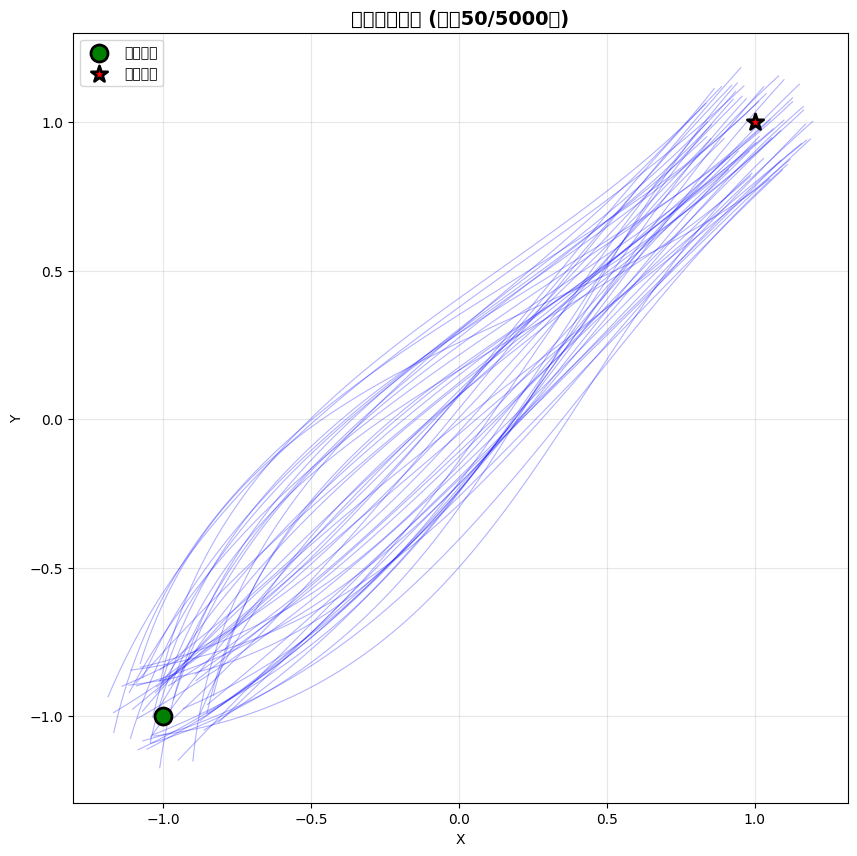

In [20]:
# ===============================================================
# 第一阶段: 生成训练数据
# ===============================================================

class TrajectoryDataset(Dataset):
    def __init__(self, trajectories):
        self.trajectories = trajectories
    
    def __len__(self):
        return len(self.trajectories)
    
    def __getitem__(self, idx):
        return torch.tensor(self.trajectories[idx], dtype=torch.float32)

def sample_point_in_circle(center, radius):
    angle = np.random.uniform(0, 2 * np.pi)
    r = radius * np.sqrt(np.random.uniform(0, 1))
    return center + r * np.array([np.cos(angle), np.sin(angle)])

def generate_bezier_curve(P0, P1, P2, P3, num_points=100):
    t = np.linspace(0, 1, num_points).reshape(-1, 1)
    B_t = (1 - t)**3 * P0 + 3 * (1 - t)**2 * t * P1 + 3 * (1 - t) * t**2 * P2 + t**3 * P3
    return B_t

# 生成训练数据
print("📊 生成Bezier轨迹训练数据...")

baseline_start = np.array([-1, -1])
baseline_end = np.array([1, 1])
radius = 0.2
perturbation_scale_P1 = 0.7
perturbation_scale_P2 = 0.01

num_trajectories = 5000  # 减少到5000条以加快训练
trajectories = []

for i in range(num_trajectories):
    P0 = sample_point_in_circle(baseline_start, radius)
    P3 = sample_point_in_circle(baseline_end, radius)
    
    base_vector = P3 - P0
    perp_vector = np.array([-base_vector[1], base_vector[0]])
    perp_vector = perp_vector / (np.linalg.norm(perp_vector) + 1e-8)
    
    P1 = P0 + base_vector / 3.0 + np.random.uniform(-perturbation_scale_P1, perturbation_scale_P1) * perp_vector
    P2 = P0 + 2 * base_vector / 3.0 + np.random.uniform(-perturbation_scale_P2, perturbation_scale_P2) * perp_vector
    
    curve = generate_bezier_curve(P0, P1, P2, P3, num_points=100)
    trajectories.append(curve.T)  # (2, 100)

trajectories = np.array(trajectories)  # (5000, 2, 100)

print(f"✅ 生成完成: {trajectories.shape}")

# 可视化训练数据样本
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
num_display = 50
for i in range(num_display):
    ax.plot(trajectories[i, 0], trajectories[i, 1], 'b-', alpha=0.3, linewidth=0.8)
ax.scatter(baseline_start[0], baseline_start[1], c='green', s=150, marker='o', 
          edgecolors='black', linewidths=2, zorder=5, label='起点区域')
ax.scatter(baseline_end[0], baseline_end[1], c='red', s=150, marker='*', 
          edgecolors='black', linewidths=2, zorder=5, label='终点区域')
ax.set_title(f'训练数据样本 (显示{num_display}/{num_trajectories}条)', fontsize=14, fontweight='bold')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.axis('equal')
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

In [21]:
# ===============================================================
# 第一阶段: Flow Matching模型训练
# ===============================================================

print("="*70)
print("开始训练Flow Matching模型")
print("="*70)

# 创建模型
unet_1d = SimpleUNet1D(time_emb_dim=128, hidden_dim=128).to(device)
wrapped_model = ModelWrapper(unet_1d)

# 优化器
optimizer = torch.optim.AdamW(unet_1d.parameters(), lr=2e-4, weight_decay=1e-5)

# Flow Matching组件
scheduler = CondOTScheduler()
path = AffinePath(scheduler=scheduler)

# 数据加载
dataset = TrajectoryDataset(trajectories)
dataloader = DataLoader(dataset, batch_size=256, shuffle=True, num_workers=0)

# 学习率调度器
scheduler_lr = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100)

# 训练参数
num_epochs = 100  # 减少epochs以加快演示
loss_history = []

print(f"\n模型参数: {sum(p.numel() for p in unet_1d.parameters()):,}")
print(f"训练epochs: {num_epochs}")
print(f"Batch size: 256")
print()

# 训练循环
for epoch in range(num_epochs):
    unet_1d.train()
    epoch_loss = 0.0
    num_batches = 0
    
    for batch in dataloader:
        z1 = batch.to(device)  # 真实轨迹
        z0 = torch.randn_like(z1)  # 噪声
        
        # 随机时间
        t = torch.rand(z1.shape[0], device=device)
        
        # Flow Matching采样
        path_sample = path.sample(x_0=z0, x_1=z1, t=t)
        
        # 预测速度场
        pred = unet_1d(path_sample.x_t, t)
        
        # 损失
        loss = F.mse_loss(pred, path_sample.dx_t)
        
        # 优化
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(unet_1d.parameters(), 1.0)
        optimizer.step()
        
        epoch_loss += loss.item()
        num_batches += 1
        loss_history.append(loss.item())
    
    scheduler_lr.step()
    avg_loss = epoch_loss / num_batches
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d}/{num_epochs}: Loss={avg_loss:.6f}, LR={scheduler_lr.get_last_lr()[0]:.6f}")

print("\n✅ Flow Matching训练完成!")

# 保存模型
torch.save({
    'model_state_dict': unet_1d.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'epoch': num_epochs,
    'loss_history': loss_history, 
}, 'fm_model_dmpc.pth')
print("💾 模型已保存: fm_model_dmpc.pth")

开始训练Flow Matching模型

模型参数: 2,833,922
训练epochs: 100
Batch size: 256

Epoch  10/100: Loss=0.051068, LR=0.000195
Epoch  20/100: Loss=0.040576, LR=0.000181
Epoch  30/100: Loss=0.034160, LR=0.000159
Epoch  40/100: Loss=0.032728, LR=0.000131
Epoch  50/100: Loss=0.031748, LR=0.000100
Epoch  60/100: Loss=0.030798, LR=0.000069
Epoch  70/100: Loss=0.029265, LR=0.000041
Epoch  80/100: Loss=0.028522, LR=0.000019
Epoch  90/100: Loss=0.027843, LR=0.000005
Epoch 100/100: Loss=0.028109, LR=0.000000

✅ Flow Matching训练完成!
💾 模型已保存: fm_model_dmpc.pth


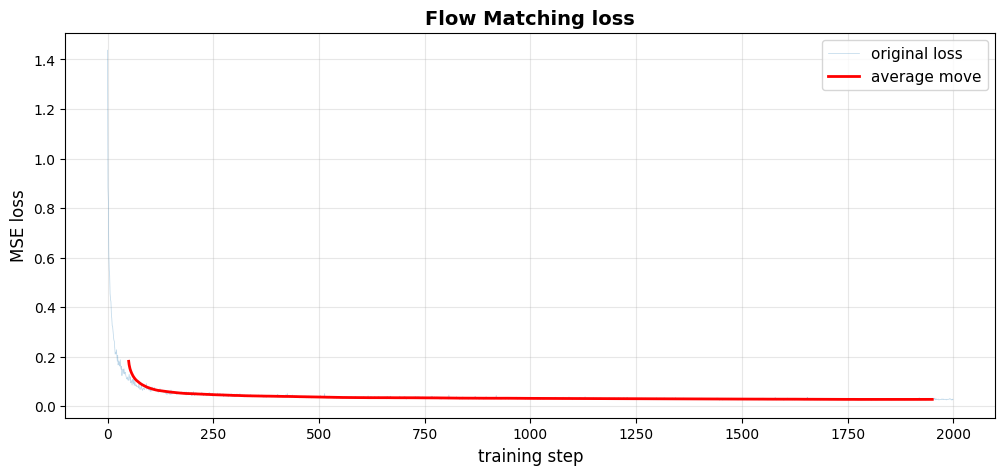

final loss: 0.028466
最后100步平均损失: 0.028007


In [22]:
# 可视化训练损失
fig, ax = plt.subplots(1, 1, figsize=(12, 5))
ax.plot(loss_history, alpha=0.3, label='original loss', linewidth=0.5)

# 移动平均
if len(loss_history) > 100:
    ma = np.convolve(loss_history, np.ones(100)/100, mode='valid')
    ax.plot(range(50, 50+len(ma)), ma, 'r-', linewidth=2, label='average move')

ax.set_xlabel('training step', fontsize=12)
ax.set_ylabel('MSE loss', fontsize=12)
ax.set_title('Flow Matching loss', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)
plt.show()

print(f"final loss: {loss_history[-1]:.6f}")
print(f"最后100步平均损失: {np.mean(loss_history[-100:]):.6f}")

In [ ]:
# ===============================================================
# 第二阶段: DMPC 代价函数 (stage cost + terminal cost)
# ===============================================================

def compute_stage_cost(
    x: np.ndarray,
    u: np.ndarray,
    goal: np.ndarray,
    obstacles,
    w_goal: float = 1.0,
    w_u: float = 0.1,
    w_obs: float = 5.0,
    safe_margin: float = 0.1,
):
#input：xk当前步的位置 uk当前步的速度向量

    """
    单步 stage cost ℓ(x_k, u_k):
        ℓ(x_k,u_k) = w_goal * ||x_k - goal||^2
                    + w_u    * ||u_k||^2
                    + w_obs  * obs_penalty(x_k)

    注意：这是“代价”，越小越好。
    """

    # 1) 到目标的偏差 cost
    goal_cost = w_goal * np.linalg.norm(x - goal)**2

    # 2) 控制 effort cost
    control_cost = w_u * np.linalg.norm(u)**2

    # 3) 障碍物 soft-penalty
    obs_cost = 0.0
    min_dist = np.inf
    for obs in obstacles:
        center = obs["center"]
        radius = obs["radius"]
        d_center = np.linalg.norm(x - center)       # 点到圆心距离
        d_boundary = d_center - radius              # 点到障碍物边界的距离
        min_dist = min(min_dist, d_boundary)
        # 如果靠得太近（小于安全距离），往里罚
        if d_boundary < safe_margin:
            obs_cost += (safe_margin - d_boundary)**2

    obs_cost *= w_obs

    stage_cost = goal_cost + control_cost + obs_cost

    detail = {
        "goal_cost": float(goal_cost),
        "control_cost": float(control_cost),
        "obs_cost": float(obs_cost),
        "min_dist": float(min_dist),
        "stage_cost": float(stage_cost),
    }
    return stage_cost, detail


def compute_terminal_cost(
    x: np.ndarray,
    goal: np.ndarray,
    w_terminal: float = 5.0,
):
    """
    终端 cost V(x_H):
        V(x_H) = w_terminal * ||x_H - goal||^2
    """
    term_cost = w_terminal * np.linalg.norm(x - goal)**2
    return term_cost


def evaluate_trajectory_cost(
    trajectory: np.ndarray,
    goal: np.ndarray,
    obstacles,
    dt: float = 0.02,
    w_goal: float = 1.0,
    w_u: float = 0.1,
    w_obs: float = 5.0,
    w_terminal: float = 5.0,
    safe_margin: float = 0.1,
):
    """
    计算一整条轨迹的总 cost：

        J = Σ_{k=0}^{T-2} ℓ(x_k, u_k) + V(x_{T-1})

    trajectory: shape (2, T)
    返回:
        total_cost: 标量
        diagnostics: 分量信息，方便可视化和调试
    """
    traj = np.asarray(trajectory)
    assert traj.ndim == 2 and traj.shape[0] == 2, "trajectory 应为 (2, T)"

    T = traj.shape[1]
    total_cost = 0.0

    goal_costs = []
    control_costs = []
    obs_costs = []
    min_dists = []
    stage_costs = []

    # —— stage cost 累积 ——
    for k in range(T - 1):
        x_k = traj[:, k]
        x_next = traj[:, k + 1]
        # 控制量：用相邻状态差分近似速度
        u_k = (x_next - x_k) / dt

        c_k, detail_k = compute_stage_cost(
            x_k,
            u_k,
            goal,
            obstacles,
            w_goal=w_goal,
            w_u=w_u,
            w_obs=w_obs,
            safe_margin=safe_margin,
        )
        total_cost += c_k

        goal_costs.append(detail_k["goal_cost"])
        control_costs.append(detail_k["control_cost"])
        obs_costs.append(detail_k["obs_cost"])
        min_dists.append(detail_k["min_dist"])
        stage_costs.append(detail_k["stage_cost"])

    # —— terminal cost ——
    x_T = traj[:, -1]
    term_cost = compute_terminal_cost(x_T, goal, w_terminal=w_terminal)
    total_cost += term_cost

    diagnostics = {
        "total_cost": float(total_cost),
        "stage_costs": np.array(stage_costs),
        "goal_costs": np.array(goal_costs),
        "control_costs": np.array(control_costs),
        "obs_costs": np.array(obs_costs),
        "min_dists": np.array(min_dists),
        "terminal_cost": float(term_cost),
        "x_terminal": x_T.copy(),
    }

    return total_cost, diagnostics

print("✅ DMPC 代价函数 (stage + terminal) 已定义完成")


✅ DMPC 代价函数 (stage + terminal) 已定义完成


In [53]:
# ===============================================================
# Flow Matching轨迹采样函数（不再用 AffinePath / ODESolver）
# 直接用训练好的 unet_1d 做速度场，用 Euler 积分生成轨迹
# ===============================================================
import torch
import numpy as np

@torch.no_grad()
def sample_fm_trajectory(model, start, goal, obstacles, horizon=50, device='cpu'):
    """
    使用 Flow Matching 生成候选轨迹

    参数:
        model: 训练好的 UNet1D（unet_1d），输入 (B, 2, T) 和 (B,) 的时间 t
        start: 起点 (2,)
        goal:  终点 (2,)
        obstacles: 障碍物列表（这里先不在 FM 里用，接口保留）
        horizon: 轨迹点数
    返回:
        trajectory: (2, horizon) NumPy数组
    """
    model.eval()

    start = np.asarray(start, dtype=float).reshape(2)
    goal  = np.asarray(goal,  dtype=float).reshape(2)

    # ---- 1) 构造一条线性插值的“基准轨迹”（只用作条件，不是最终结果）----
    t_grid = np.linspace(0.0, 1.0, horizon)
    baseline = np.zeros((1, 2, horizon), dtype=np.float32)
    for i, s in enumerate(t_grid):
        baseline[0, :, i] = (1.0 - s) * start + s * goal

    baseline = torch.tensor(baseline, dtype=torch.float32, device=device)

    # ---- 2) 在基准轨迹上加一点噪声作为初始 x(τ=0) ----
    noise = torch.randn_like(baseline)
    x = baseline + 0.1 * noise  # 0.1 可以调，控制 FM 偏离直线的程度

    # 保证首尾刚性等于 start / goal
    x[:, :, 0]  = baseline[:, :, 0]
    x[:, :, -1] = baseline[:, :, -1]

    # ---- 3) 用 Flow Matching 学出来的速度场做 ODE 积分 ----
    # τ 从 0 积分到 1，这个 τ 是 FM 的“时间”
    n_steps = 40             # ODE 步数，可以调大一点更平滑
    d_tau   = 1.0 / n_steps

    for k in range(n_steps):
        tau = k / n_steps
        t_batch = torch.full((1,), tau, dtype=torch.float32, device=device)  # (B,)

        # unet_1d 在训练时就是用了 (x_t, t) 这个接口
        v = model(x, t_batch)   # 形状应为 (1, 2, horizon)，和 x 一样

        # Euler 积分：x_{τ+Δτ} = x_τ + Δτ * v(x_τ, τ)
        x = x + d_tau * v

        # 每步都重新对齐首尾点，保证满足起点/终点条件
        x[:, :, 0]  = baseline[:, :, 0]
        x[:, :, -1] = baseline[:, :, -1]

    traj = x[0].detach().cpu().numpy()  # (2, horizon)
    return traj


In [ ]:
# ===============================================================
# Flow Matching轨迹采样函数（不再用 AffinePath / ODESolver）
# 直接用训练好的 unet_1d 做速度场，用 Euler 积分生成轨迹
# ===============================================================
import torch
import numpy as np

@torch.no_grad()
def sample_fm_trajectory(model, start, goal, obstacles, horizon=50, device='cpu'):
    """
    使用 Flow Matching 生成候选轨迹

    参数:
        model: 训练好的 UNet1D（unet_1d），输入 (B, 2, T) 和 (B,) 的时间 t
        start: 起点 (2,)
        goal:  终点 (2,)
        obstacles: 障碍物列表（这里先不在 FM 里用，接口保留）
        horizon: 轨迹点数
    返回:
        trajectory: (2, horizon) NumPy数组
    """
    model.eval()

    start = np.asarray(start, dtype=float).reshape(2) #(2,) 形状的 NumPy 数组
    goal  = np.asarray(goal,  dtype=float).reshape(2)

    # ---- 1) 构造一条线性插值的“基准轨迹”（只用作条件，不是最终结果）----
    t_grid = np.linspace(0.0, 1.0, horizon) #创建从 0 到 1 的时间网格，共 horizon 个点
    baseline = np.zeros((1, 2, horizon), dtype=np.float32) #baseline 形状：(1, 2, horizon) 1,batch size, 2xy坐标
    for i, s in enumerate(t_grid):
        baseline[0, :, i] = (1.0 - s) * start + s * goal

    baseline = torch.tensor(baseline, dtype=torch.float32, device=device)

    # ---- 2) 在基准轨迹上加一点噪声作为初始 x(τ=0) ----
    noise = torch.randn_like(baseline)
    x = baseline + 0.1 * noise  # 0.1 可以调，控制 FM 偏离直线的程度

    # 保证首尾刚性等于 start / goal
    x[:, :, 0]  = baseline[:, :, 0]
    x[:, :, -1] = baseline[:, :, -1]

    # ---- 3) 用 Flow Matching 学出来的速度场做 ODE 积分 ----
    # τ 从 0 积分到 1，这个 τ 是 FM 的“时间”
    n_steps = 40             # ODE 步数，可以调大一点更平滑
    d_tau   = 1.0 / n_steps #计算当前的 FM 时间 τ 这个 τ 是 Flow Matching 的"流动时间"

    for k in range(n_steps):
        tau = k / n_steps
        t_batch = torch.full((1,), tau, dtype=torch.float32, device=device)  # (B,)

        # unet_1d 在训练时就是用了 (x_t, t) 这个接口
        v = model(x, t_batch)   # 形状应为 (1, 2, horizon)，和 x 一样 调用训练好的 UNet1D 模型，输入当前轨迹 x 和时间 t_batch，输出速度场 v。这个 v 就是

        # Euler 积分：x_{τ+Δτ} = x_τ + Δτ * v(x_τ, τ)
        x = x + d_tau * v

        # 每步都重新对齐首尾点，保证满足起点/终点条件
        x[:, :, 0]  = baseline[:, :, 0]
        x[:, :, -1] = baseline[:, :, -1]

    traj = x[0].detach().cpu().numpy()  # (2, horizon)
    return traj


In [ ]:
# ===============================================================
# 第二阶段: DMPC 单步 (shooting MPC + CBF 安全滤波)
# ===============================================================

def dmpc_step(
    model,
    current: np.ndarray,
    goal: np.ndarray,
    obstacles,
    dt: float = 0.02,
    horizon: int = 50,
    n_candidates: int = 8,
    use_cbf: bool = True,
    max_speed: float = 1.0,
    cost_params: dict = None,
    device: str = device,
):
    """
    DMPC 单步：
        1) 用 Flow Matching 采样 n_candidates 条候选轨迹
        2) 对每条轨迹计算 cost (stage + terminal)
        3) 选 cost 最小的一条，取其第一个控制量 u0_nom
        4) 用 CBF QP 对 u0_nom 做安全投影得到 u0_safe
        5) 用 u0_safe 推进环境得到 next_state

    返回:
        next_state: (2,)
        info: {包含最佳轨迹、u_nom、u_safe、cost 等诊断信息}
    """

    if cost_params is None:
        cost_params = {}

    current = np.asarray(current, dtype=float)
    goal = np.asarray(goal, dtype=float)

    best_cost = np.inf
    best_traj = None
    best_cost_detail = None

    candidate_trajs = []
    candidate_costs = []

    # ---------- 1) 采样候选轨迹 ----------
    for i in range(n_candidates):
        try:
            traj_candidate = sample_fm_trajectory(
                model=model,
                start=current,
                goal=goal,
                obstacles=obstacles,
                horizon=horizon,
                device=device,
            )
        except Exception as e:
            # backup: 线性插值
            t_grid = np.linspace(0.0, 1.0, horizon)
            traj_candidate = np.zeros((2, horizon), dtype=float)
            for k, tau in enumerate(t_grid):
                traj_candidate[:, k] = current + tau * (goal - current)

        # 保证形状正确
        traj_candidate = np.asarray(traj_candidate, dtype=float)
        if traj_candidate.shape != (2, horizon):
            # 如果 solver 返回 T 不一致，简单插值到 horizon
            T_now = traj_candidate.shape[1]
            grid_old = np.linspace(0.0, 1.0, T_now)
            grid_new = np.linspace(0.0, 1.0, horizon)
            traj_interp = np.zeros((2, horizon))

            #这段代码是在做轨迹重采样，把长度不对的轨迹插值到正确的长度
            #你期望轨迹长度是 horizon = 50 T_now = 30
            for dim in range(2):
                traj_interp[dim] = np.interp(grid_new, grid_old, traj_candidate[dim])
            traj_candidate = traj_interp

        # ---------- 2) 计算该轨迹的 cost ----------
        J_i, detail_i = evaluate_trajectory_cost(
            traj_candidate,
            goal=goal,
            obstacles=obstacles,
            dt=dt,
            **cost_params,
        )

        candidate_trajs.append(traj_candidate)
        candidate_costs.append(J_i)

        # ---------- 3) 选 cost 最小 ----------
        if J_i < best_cost:
            best_cost = J_i
            best_traj = traj_candidate
            best_cost_detail = detail_i

    candidate_trajs = np.stack(candidate_trajs, axis=0)  # (n_candidates, 2, horizon)
    candidate_costs = np.array(candidate_costs)

    # ---------- 4) 取最佳轨迹的第一个控制量 ----------
    x0 = best_traj[:, 0]
    x1 = best_traj[:, 1]
    u_nom = (x1 - x0) / dt

    # ---------- 5) CBF 安全滤波 ----------
    if use_cbf and len(obstacles) > 0:
        u_safe, cbf_diag = solve_cbf_qp(
            pos=current,
            u_nom=u_nom,
            goal=goal,
            obstacles=obstacles,
            # 可以根据需要调整
            alpha=0.8,
            gamma=1.0,
            slack_weight=500.0,
            max_speed=max_speed,
        )
    else:
        u_safe = u_nom
        cbf_diag = {}

    # 限制速度
    u_norm = np.linalg.norm(u_safe)
    if u_norm > max_speed:
        u_safe = u_safe / (u_norm + 1e-8) * max_speed

    # ---------- 6) 用 u_safe 推进到下一步 ----------
    next_state = current + u_safe * dt

    info = {
        "best_traj": best_traj,
        "best_cost": float(best_cost),
        "best_cost_detail": best_cost_detail,
        "candidate_trajs": candidate_trajs,
        "candidate_costs": candidate_costs,
        "u_nom": u_nom,
        "u_safe": u_safe,
        "cbf_diag": cbf_diag,
    }

    return next_state, info

print("✅ DMPC 单步 dmpc_step 已定义完成")


✅ DMPC 单步 dmpc_step 已定义完成


In [68]:
# ===============================================================
# CBF 安全滤波器: solve_cbf_qp
# ===============================================================

import numpy as np

try:
    import cvxpy as cp
    _HAS_CVXPY = True
except Exception:
    print("⚠️ 未安装 cvxpy，CBF 将退化为直接使用 u_nom（只做速度裁剪）")
    _HAS_CVXPY = False


def cbf_h(pos: np.ndarray, obs: dict) -> float:
    """
    CBF 值：
        h(x) = ||x - c||^2 - r^2
    h(x) >= 0 表示在障碍物外面
    """
    center = obs["center"]
    radius = obs["radius"]
    return float(np.linalg.norm(pos - center) ** 2 - radius ** 2)


def cbf_grad_h(pos: np.ndarray, obs: dict) -> np.ndarray:
    """
    ∂h/∂x = 2 (x - c)
    """
    center = obs["center"]
    return 2.0 * (pos - center)


def solve_cbf_qp(
    pos: np.ndarray,
    u_nom: np.ndarray,
    goal: np.ndarray,
    obstacles,
    alpha: float = 0.8,
    gamma: float = 1.0,
    slack_weight: float = 500.0,
    max_speed: float = 1.0,
):
    """
    给定当前位置 pos 和名义控制 u_nom，
    通过一个小 QP 做 CBF 安全投影，得到 u_safe。

    QP:
        min   ||u - u_nom||^2 + slack_weight * s^2
        s.t.  ∂h_i/∂x · u + α h_i(x) ≥ -s        (对每个障碍物)
              ||u||_2 ≤ max_speed

    若 cvxpy 不可用，退化为：只对 u_nom 做速度裁剪。
    """
    pos = np.asarray(pos, dtype=float)
    u_nom = np.asarray(u_nom, dtype=float)

    if (not _HAS_CVXPY) or (len(obstacles) == 0):
        # 没有 cvxpy 或没有障碍物：直接裁剪速度返回
        u_safe = u_nom.copy()
        norm_u = np.linalg.norm(u_safe)
        if norm_u > max_speed:
            u_safe = u_safe / (norm_u + 1e-8) * max_speed
        diag = {
            "status": "no_cvxpy_or_no_obstacles",
            "u_nom": u_nom,
            "u_safe": u_safe,
        }
        return u_safe, diag

    # ---------- 定义优化变量 ----------
    u = cp.Variable(2)
    slack = cp.Variable(nonneg=True)

    constraints = []

    # ---------- CBF 约束 ----------
    for obs in obstacles:
        h_val = cbf_h(pos, obs)
        grad_h = cbf_grad_h(pos, obs)  # shape (2,)

        # 约束: grad_h^T u + alpha * h(x) >= - slack
        constraints.append(grad_h @ u + alpha * h_val >= -slack)

    # ---------- 速度上界约束 ----------
    constraints.append(cp.norm(u, 2) <= max_speed)

    # ---------- 目标函数 ----------
    u_nom_const = u_nom.astype(float)
    objective = cp.Minimize(cp.sum_squares(u - u_nom_const) + slack_weight * cp.square(slack))

    prob = cp.Problem(objective, constraints)

    try:
        prob.solve(solver=cp.OSQP, warm_start=True)
    except Exception:
        prob.solve(warm_start=True)

    if u.value is None:
        # QP 失败，退回名义控制 + 裁剪
        u_safe = u_nom.copy()
        norm_u = np.linalg.norm(u_safe)
        if norm_u > max_speed:
            u_safe = u_safe / (norm_u + 1e-8) * max_speed
        diag = {
            "status": "qp_failed",
            "u_nom": u_nom,
            "u_safe": u_safe,
        }
        return u_safe, diag

    u_safe = np.array(u.value).reshape(-1)
    norm_u = np.linalg.norm(u_safe)
    if norm_u > max_speed:
        u_safe = u_safe / (norm_u + 1e-8) * max_speed

    diag = {
        "status": prob.status,
        "obj_val": float(prob.value),
        "u_nom": u_nom,
        "u_safe_raw": np.array(u.value).reshape(-1),
        "u_safe": u_safe,
        "slack": float(slack.value),
    }

    return u_safe, diag


print("✅ CBF 安全滤波器 solve_cbf_qp 已定义完成")


✅ CBF 安全滤波器 solve_cbf_qp 已定义完成


In [37]:
# ===============================================================
# 第二阶段: 设置环境并执行 DMPC episode
# ===============================================================
#device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def run_dmpc_episode(
    model,
    start_pos: np.ndarray,
    goal_pos: np.ndarray,
    obstacles,
    max_steps: int = 200,
    dt: float = 0.02,
    horizon: int = 50,
    n_candidates: int = 8,
    max_speed: float = 1.0,
    cost_params: dict = None,
    device: str = device,
):
    """
    从 start_pos 出发，使用 dmpc_step 一步步滚动，直到：
        - 到达目标附近，或
        - 达到 max_steps

    返回:
        states: (2, N_steps+1)
        u_nom_list: (N_steps, 2)
        u_safe_list: (N_steps, 2)
        cost_list: (N_steps,)
        info_history: 每一步的 info
    """
    current = np.asarray(start_pos, dtype=float)
    goal = np.asarray(goal_pos, dtype=float)

    states = [current.copy()]
    u_nom_list = []
    u_safe_list = []
    cost_list = []
    info_history = []

    for step in range(max_steps):
        # 结束条件：离目标足够近
        if np.linalg.norm(current - goal) < 0.1:
            print(f"✅ 在第 {step} 步收敛到目标附近")
            break

        next_state, info = dmpc_step(
            model=model,
            current=current,
            goal=goal,
            obstacles=obstacles,
            dt=dt,
            horizon=horizon,
            n_candidates=n_candidates,
            use_cbf=True,
            max_speed=max_speed,
            cost_params=cost_params,
            device=device,
        )

        states.append(next_state.copy())
        u_nom_list.append(info["u_nom"])
        u_safe_list.append(info["u_safe"])
        cost_list.append(info["best_cost"])
        info_history.append(info)

        current = next_state

    states = np.stack(states, axis=1)          # (2, N_steps+1)
    u_nom_list = np.array(u_nom_list)         # (N_steps, 2)
    u_safe_list = np.array(u_safe_list)       # (N_steps, 2)
    cost_list = np.array(cost_list)           # (N_steps,)

    return states, u_nom_list, u_safe_list, cost_list, info_history


# ========== 配置场景并运行 ==========
# 障碍物配置 (可以自己改)
obstacles = [
    {"center": np.array([0.0, 0.0]), "radius": 0.25},
    {"center": np.array([0.5, 0.5]), "radius": 0.2},
]

start_pos = np.array([-0.7, -0.6])
goal_pos = np.array([0.8, 0.7])

# cost 权重
cost_params = dict(
    w_goal=1.0,
    w_u=0.05,
    w_obs=10.0,
    w_terminal=5.0,
    safe_margin=0.08,
)

print("=" * 80)
print("开始运行 DMPC episode ...")
states_traj, u_nom_traj, u_safe_traj, cost_traj, info_hist = run_dmpc_episode(
    model=unet_1d,
    start_pos=start_pos,
    goal_pos=goal_pos,
    obstacles=obstacles,
    max_steps=200,
    dt=0.02,
    horizon=50,
    n_candidates=8,
    max_speed=1.0,
    cost_params=cost_params,
    device=device,
)
print("DMPC episode 运行结束")
print("=" * 80)


开始运行 DMPC episode ...
DMPC episode 运行结束


In [ ]:
# ===============================================================
# 第二阶段: 设置环境并执行 DMPC episode
# ===============================================================

def run_dmpc_episode(
    model,
    start_pos: np.ndarray,
    goal_pos: np.ndarray,
    obstacles,
    max_steps: int = 300,
    dt: float = 0.02,
    horizon: int = 50,
    n_candidates: int = 8,
    max_speed: float = 1.0,
    cost_params: dict = None,
    device: str = device,
):
    """
    从 start_pos 出发，使用 dmpc_step 一步步滚动，直到：
        - 到达目标附近，或
        - 达到 max_steps

    返回:
        states: (2, N_steps+1)
        u_nom_list: (N_steps, 2)
        u_safe_list: (N_steps, 2)
        cost_list: (N_steps,)
        info_history: 每一步的 info
    """
    current = np.asarray(start_pos, dtype=float)
    goal = np.asarray(goal_pos, dtype=float)

    states = [current.copy()]
    u_nom_list = []  # 存储名义控制量
    u_safe_list = [] ## 存储安全控制量
    cost_list = []
    info_history = []

    #receding Horizon Process
    for step in range(max_steps):
        # 结束条件：离目标足够近
        if np.linalg.norm(current - goal) < 0.05:
            print(f"✅ 在第 {step} 步收敛到目标附近")
            break
        #执行单步循环
        next_state, info = dmpc_step(
            model=model,
            current=current,
            goal=goal,
            obstacles=obstacles,
            dt=dt,
            horizon=horizon,
            n_candidates=n_candidates,
            use_cbf=True,
            max_speed=max_speed,
            cost_params=cost_params,
            device=device,
        )

        states.append(next_state.copy())
        u_nom_list.append(info["u_nom"])
        u_safe_list.append(info["u_safe"])
        cost_list.append(info["best_cost"])
        info_history.append(info)

        current = next_state

    states = np.stack(states, axis=1)          # (2, N_steps+1)
    u_nom_list = np.array(u_nom_list)         # (N_steps, 2)
    u_safe_list = np.array(u_safe_list)       # (N_steps, 2)
    cost_list = np.array(cost_list)           # (N_steps,)

    return states, u_nom_list, u_safe_list, cost_list, info_history


# ========== 配置场景并运行 ==========
# 障碍物配置 (可以自己改)
obstacles = [
    {"center": np.array([0.0, 0.0]), "radius": 0.25},
    {"center": np.array([0.5, 0.5]), "radius": 0.2},
]

start_pos = np.array([-0.7, -0.6])
goal_pos = np.array([0.8, 0.7])

# cost 权重
cost_params = dict(
    w_goal=1.0,
    w_u=0.05,
    w_obs=10.0,
    w_terminal=5.0,
    safe_margin=0.08,
)

print("=" * 80)
print("开始运行 DMPC episode ...")
states_traj, u_nom_traj, u_safe_traj, cost_traj, info_hist = run_dmpc_episode(
    model=unet_1d,
    start_pos=start_pos,
    goal_pos=goal_pos,
    obstacles=obstacles,
    max_steps=200,
    dt=0.02,
    horizon=50,
    n_candidates=8,
    max_speed=1.0,
    cost_params=cost_params,
    device=device,
)
print("DMPC episode 运行结束")
print("=" * 80)


开始运行 DMPC episode ...
DMPC episode 运行结束


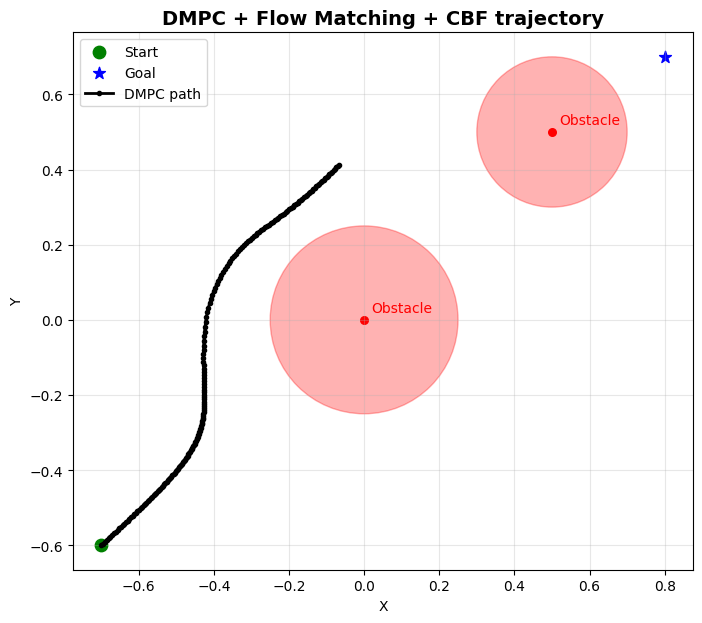

In [77]:
# ===============================================================
# 第二阶段: 可视化 DMPC 轨迹与障碍物
# ===============================================================

fig, ax = plt.subplots(1, 1, figsize=(8, 8))

# 绘制障碍物
for obs in obstacles:
    c = obs["center"]
    r = obs["radius"]
    circle = Circle(c, r, color="red", alpha=0.3)
    ax.add_patch(circle)
    ax.scatter(c[0], c[1], c="red", s=30)
    ax.text(c[0] + 0.02, c[1] + 0.02, "Obstacle", color="red")

# 起点和终点
ax.scatter(start_pos[0], start_pos[1], c="green", s=80, marker="o", label="Start")
ax.scatter(goal_pos[0], goal_pos[1], c="blue", s=80, marker="*", label="Goal")

# 执行轨迹
ax.plot(states_traj[0], states_traj[1], "k-o", linewidth=2, markersize=3, label="DMPC path")

ax.set_aspect("equal", "box")
ax.grid(True, alpha=0.3)
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_title("DMPC + Flow Matching + CBF trajectory", fontsize=14, fontweight="bold")
ax.legend()
plt.show()


C:\Users\ROG\AppData\Local\Temp\ipykernel_24364\753654407.py:40: UserWarning: Glyph 27599 (\N{CJK UNIFIED IDEOGRAPH-6BCF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ROG\AppData\Local\Temp\ipykernel_24364\753654407.py:40: UserWarning: Glyph 27493 (\N{CJK UNIFIED IDEOGRAPH-6B65}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ROG\AppData\Local\Temp\ipykernel_24364\753654407.py:40: UserWarning: Glyph 26368 (\N{CJK UNIFIED IDEOGRAPH-6700}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ROG\AppData\Local\Temp\ipykernel_24364\753654407.py:40: UserWarning: Glyph 20339 (\N{CJK UNIFIED IDEOGRAPH-4F73}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ROG\AppData\Local\Temp\ipykernel_24364\753654407.py:40: UserWarning: Glyph 36712 (\N{CJK UNIFIED IDEOGRAPH-8F68}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ROG\AppData\Local\Temp\ipykernel_24364\753654407.py:40: UserWarning: Glyph 36857 (\N{CJK UNIFIED IDEO

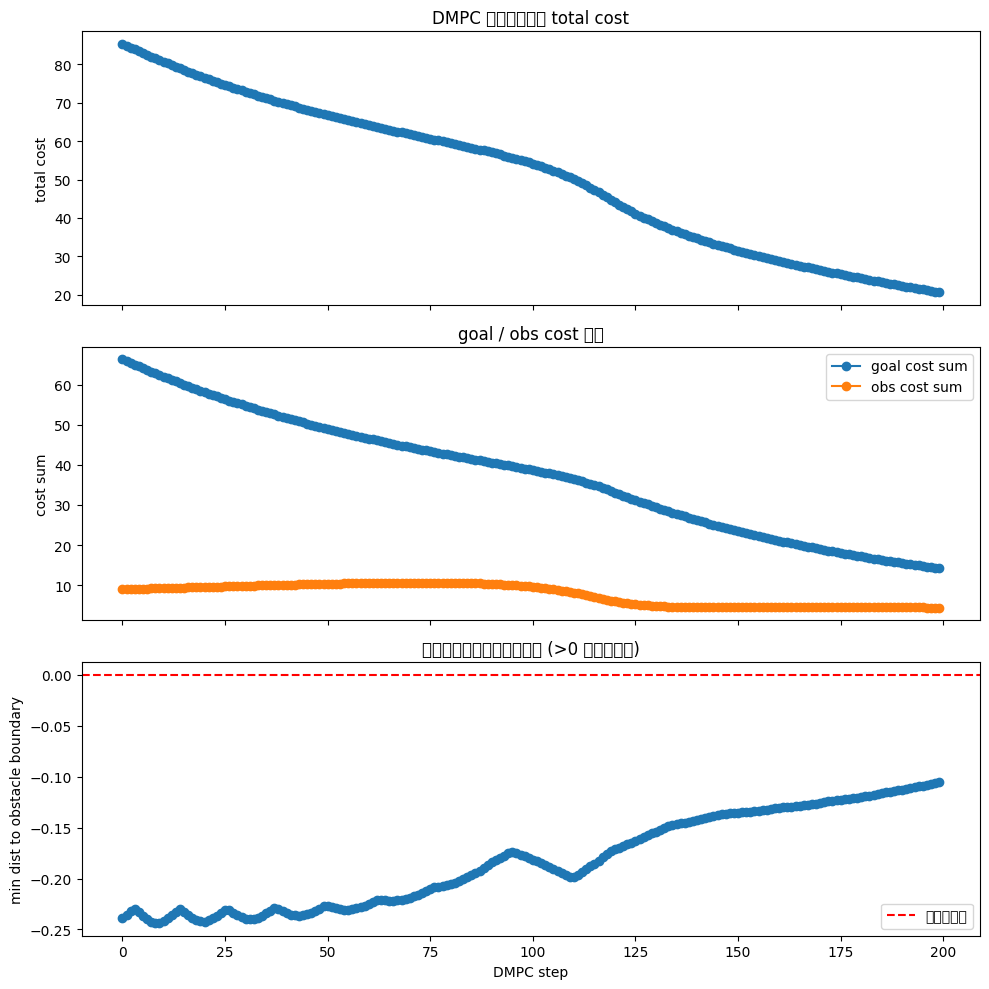

总共 DMPC 步数: 200
最终与目标距离: 0.9133


In [40]:
# ===============================================================
# 第二阶段: cost 诊断曲线 (总 cost / min_dist 等)
# ===============================================================

# 取每一步 DMPC 选出来的最佳轨迹的第一个 stage 的信息
step_min_dists = []
step_obs_costs = []
step_goal_costs = []

for info in info_hist:
    detail = info["best_cost_detail"]
    # 取这一条轨迹里“最小距离 / 最大 obs_cost / goal_cost”
    step_min_dists.append(detail["min_dists"].min())
    step_obs_costs.append(detail["obs_costs"].sum())
    step_goal_costs.append(detail["goal_costs"].sum())

step_min_dists = np.array(step_min_dists)
step_obs_costs = np.array(step_obs_costs)
step_goal_costs = np.array(step_goal_costs)

fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

axes[0].plot(cost_traj, "-o")
axes[0].set_ylabel("total cost")
axes[0].set_title("DMPC 每步最佳轨迹 total cost")

axes[1].plot(step_goal_costs, "-o", label="goal cost sum")
axes[1].plot(step_obs_costs, "-o", label="obs cost sum")
axes[1].set_ylabel("cost sum")
axes[1].set_title("goal / obs cost 分量")
axes[1].legend()

axes[2].plot(step_min_dists, "-o")
axes[2].axhline(0.0, color="r", linestyle="--", label="障碍物边界")
axes[2].set_ylabel("min dist to obstacle boundary")
axes[2].set_xlabel("DMPC step")
axes[2].set_title("每步轨迹离障碍物最小距离 (>0 表示没穿模)")
axes[2].legend()

plt.tight_layout()
plt.show()

print(f"总共 DMPC 步数: {len(cost_traj)}")
print(f"最终与目标距离: {np.linalg.norm(states_traj[:, -1] - goal_pos):.4f}")


In [ ]:
# ===============================================================
# 双车轨迹：几何 + 时空碰撞检测函数
# ===============================================================

import numpy as np

def check_trajectory_collision_pairs(traj_A, traj_B, dt=0.02, space_eps=0.05):
    """
    先只看几何上两条轨迹是否相交（不管时间）
    再根据时间差划分：
      - geom_pairs: 所有几何上接近的点对 (i, j, dist)
      - true_collisions: 同时刻/时间差很小的“真正碰撞点”
      - async_passes: 不同时间经过同一空间位置（不算碰撞）
    """
    T_A = traj_A.shape[1]
    T_B = traj_B.shape[1]
    
    geom_pairs = []
    min_dist = float('inf')
    min_pair = None
    
    for i in range(T_A):
        for j in range(T_B):
            d = np.linalg.norm(traj_A[:, i] - traj_B[:, j])
            if d < min_dist:
                min_dist = d
                min_pair = (i, j, d)
            if d <= space_eps:
                geom_pairs.append((i, j, d))
    
    # 时间判定
    time_eps = dt * 1.5  # 可以稍微放宽一点，比如 1~2 个步长
    true_collisions = []
    async_passes = []
    
    for (i, j, d) in geom_pairs:
        t_i = i * dt
        t_j = j * dt
        dt_ij = abs(t_i - t_j)
        if dt_ij <= time_eps:
            true_collisions.append((i, j, d, dt_ij))
        else:
            async_passes.append((i, j, d, dt_ij))
    
    info = {
        "geom_pairs": geom_pairs,
        "true_collisions": true_collisions,
        "async_passes": async_passes,
        "min_dist": min_dist,
        "min_pair": min_pair,
    }
    return info

def print_collision_report(info, dt=0.02):
    """
    按照导师的逻辑打印人话报告：
      1. 有没有几何相交
      2. 相交点是不同时间经过，还是同时刻真正相撞
    """
    print("\n" + "="*70)
    print("🧪 双车轨迹碰撞分析报告")
    print("="*70)
    
    print(f"最小距离: {info['min_dist']:.4f}")
    if info["min_pair"] is not None:
        i, j, d = info["min_pair"]
        print(f"  对应索引: A_t={i}, B_t={j}, 位置距离={d:.4f}")
    
    if not info["geom_pairs"]:
        print("\n1️⃣ 轨迹几何上没有任何相交点（距离始终 > 阈值），✅ 不算碰撞。")
        return
    
    print(f"\n1️⃣ 轨迹几何上存在 {len(info['geom_pairs'])} 个接近点（可能相交）。")
    
    if info["true_collisions"]:
        print(f"\n2️⃣ 在这些接近点中，有 {len(info['true_collisions'])} 个属于“同一时间”的真正碰撞：")
        for (i, j, d, dt_ij) in info["true_collisions"][:10]:
            print(f"   - A_t={i}, B_t={j}, 距离={d:.4f}, 时间差={dt_ij:.4f}s")
        print("\n👉 按导师标准：存在同时间同位置的重叠，所以属于❌ 碰撞。")
    else:
        print("\n2️⃣ 所有接近点的时间都不一致（时间差 > time_eps），只是不同时间经过相近位置：")
        for (i, j, d, dt_ij) in info["async_passes"][:10]:
            print(f"   - A_t={i}, B_t={j}, 距离={d:.4f}, 时间差={dt_ij:.4f}s")
        print("\n👉 按导师标准：只是错峰通过同一区域，✅ 不算碰撞。")


In [ ]:
# ===============================================================
# 双车相向行驶：FM + CBF 双向避碰 DMPC 仿真（不再用 AffinePath / solver）
# 直接复用你之前已经跑通的 sample_fm_trajectory
# ===============================================================

def simulate_two_car_dmpc_fm(model,
                          start_A, goal_A,
                          start_B, goal_B,
                          horizon=50,
                          dt=0.02,
                          safety_radius=0.15,
                          cbf_alpha=0.8,
                          clf_gamma=1.0,
                          slack_weight=500.0,
                          max_speed=2.0):
    """
    
    geom_pairs = []
    min_dist = float('inf')
    min_pair = None
    
      1. 为每辆车生成名义轨迹（无静态障碍物）
      2. 在时间轴上滚动，CBF 互相避让
    """
    print("\n" + "="*70)
    print("🚗 Step 1: 使用 Flow Matching 为双车生成名义轨迹（调用原来的 sample_fm_trajectory）")
    print("="*70)

    # 不使用静态障碍物
    obstacles_empty = []

    # --- 这里直接用你单车版本里已经能跑通的那个函数 ---
    # 为车 A 生成名义轨迹
    traj_nom_A = sample_fm_trajectory(model, start_A, goal_A,
                                      obstacles_empty, horizon=horizon, device=device)
    # 
    traj_nom_B = sample_fm_trajectory(model, start_B, goal_B,
                                      obstacles_empty, horizon=horizon, device=device)

    # 保证形状是 (2, T)
    if traj_nom_A.shape[0] != 2:
        traj_nom_A = traj_nom_A.T
    if traj_nom_B.shape[0] != 2:
        traj_nom_B = traj_nom_B.T

    T = horizon
    traj_A = np.zeros((2, T))
    traj_B = np.zeros((2, T))

    traj_A[:, 0] = start_A
    traj_B[:, 0] = start_B

    history_A = []
    history_B = []

    print("\n" + "="*70)
    print("🚗 Step 2: DMPC 循环 - 双车相向行驶 + CBF 避碰")
    print("="*70)
    
    #for t in range(T - 1):  # 循环 49 次 (0 到 48)
    for t in range(T - 1):
        pos_A = traj_A[:, t].copy()
        pos_B = traj_B[:, t].copy()

        # FM 名义下一步
        nom_next_A = traj_nom_A[:, min(t + 1, T - 1)]
        nom_next_B = traj_nom_B[:, min(t + 1, T - 1)]

        # 名义控制（差分）
        u_A_nom = (nom_next_A - pos_A) / dt
        u_B_nom = (nom_next_B - pos_B) / dt

        # 对方车辆当成“动态障碍物”
        obstacles_for_A = [{'center': pos_B, 'radius': safety_radius}]
        obstacles_for_B = [{'center': pos_A, 'radius': safety_radius}]

        # CBF+CLF QP 修正控制（这里用你原来就有的 solve_cbf_qp）
        u_A_safe, diag_A = solve_cbf_qp(pos_A, u_A_nom, goal_A,
                                        obstacles_for_A,
                                        alpha=cbf_alpha,
                                        gamma=clf_gamma,
                                        slack_weight=slack_weight,
                                        max_speed=max_speed)

        u_B_safe, diag_B = solve_cbf_qp(pos_B, u_B_nom, goal_B,
                                        obstacles_for_B,
                                        alpha=cbf_alpha,
                                        gamma=clf_gamma,
                                        slack_weight=slack_weight,
                                        max_speed=max_speed)

        # 简单积分器更新
        traj_A[:, t + 1] = pos_A + dt * u_A_safe
        traj_B[:, t + 1] = pos_B + dt * u_B_safe

        # 记录一些信息，方便以后想画别的图
        diag_A.update({
            "t": t,
            "pos": traj_A[:, t + 1].copy(),
            "u_nom": u_A_nom.copy(),
            "u_safe": u_A_safe.copy(),
        })
        diag_B.update({
            "t": t,
            "pos": traj_B[:, t + 1].copy(),
            "u_nom": u_B_nom.copy(),
            "u_safe": u_B_safe.copy(),
        })
        history_A.append(diag_A)
        history_B.append(diag_B)

    return traj_A, traj_B, traj_nom_A, traj_nom_B, history_A, history_B



🚗 Step 1: 使用 Flow Matching 为双车生成名义轨迹（调用原来的 sample_fm_trajectory）

🚗 Step 2: DMPC 循环 - 双车相向行驶 + CBF 避碰


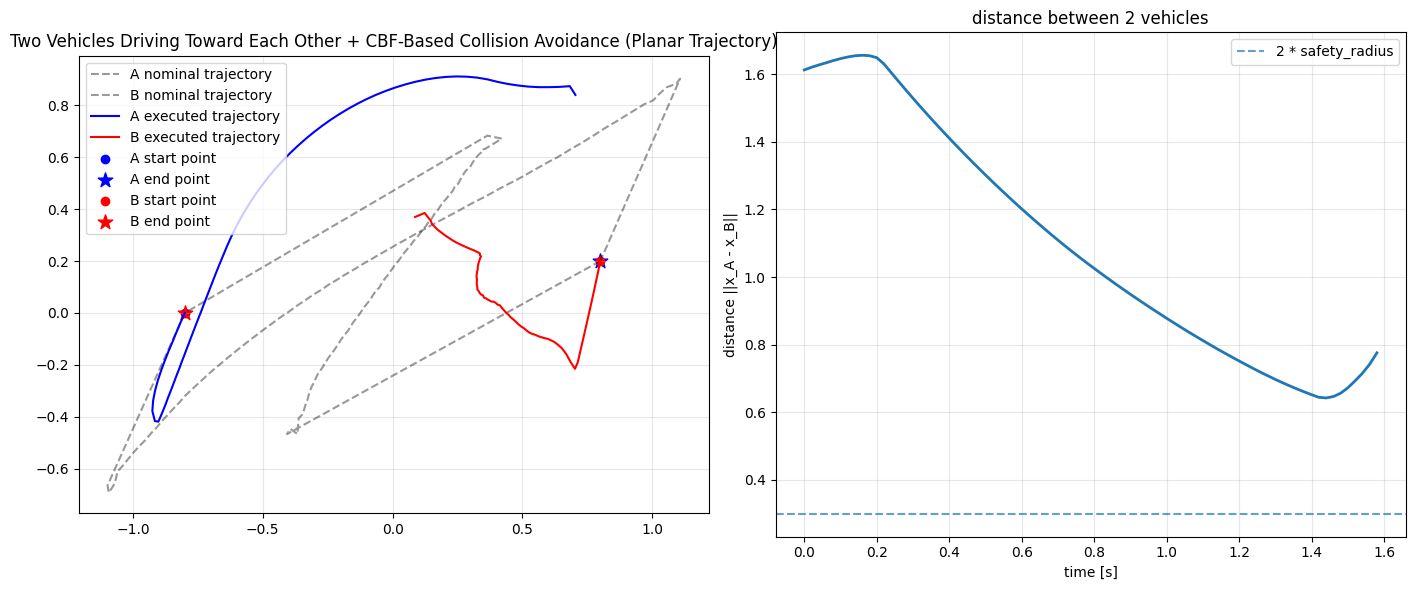


🧪 双车轨迹碰撞分析报告
最小距离: 0.4893
  对应索引: A_t=57, B_t=79, 位置距离=0.4893

1️⃣ 轨迹几何上没有任何相交点（距离始终 > 阈值），✅ 不算碰撞。


In [ ]:
# ===============================================================
# 实验：两辆小车从起点和终点相向而行，CBF 保证不相撞
# ===============================================================

# 1) 设置起点 / 终点（你可以自己改）
start_A = np.array([-0.8, 0])
goal_A  = np.array([ 0.8, 0.2])

# 车 B 反向
start_B = goal_A.copy()
goal_B  = start_A.copy()

horizon = 80
dt = 0.02
safety_radius = 0.15   # CBF 里的安全圆半径
space_eps = 0.08       # 判定“位置重叠”的阈值

# 2) 运行双车 DMPC 仿真
traj_A, traj_B, traj_nom_A, traj_nom_B, hist_A, hist_B = simulate_two_car_dmpc_fm(
    model=unet_1d,          # 这里用你前面训练好的 Flow Matching 模型变量名
    start_A=start_A,
    goal_A=goal_A,
    start_B=start_B,
    goal_B=goal_B,
    horizon=horizon,
    dt=dt,
    safety_radius=safety_radius,
    cbf_alpha=0.8,
    clf_gamma=1.0,
    slack_weight=500.0,
    max_speed=2.0,
)

# 3) 轨迹可视化：车 A / 车 B / 名义轨迹
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
ax.set_title("Two Vehicles Driving Toward Each Other + CBF-Based Collision Avoidance (Planar Trajectory)", fontsize=12)

# 名义轨迹（虚线）
ax.plot(traj_nom_A[0], traj_nom_A[1], 'k--', alpha=0.4, label="A nominal trajectory")
ax.plot(traj_nom_B[0], traj_nom_B[1], 'k--', alpha=0.4, label="B nominal trajectory")

# 实际执行轨迹（实线）
ax.plot(traj_A[0], traj_A[1], 'b-', label="A executed trajectory")
ax.plot(traj_B[0], traj_B[1], 'r-', label="B executed trajectory")

# 起点和终点
ax.scatter(start_A[0], start_A[1], c='b', marker='o', label="A start point")
ax.scatter(goal_A[0],  goal_A[1],  c='b', marker='*', s=120, label="A end point")

ax.scatter(start_B[0], start_B[1], c='r', marker='o', label="B start point")
ax.scatter(goal_B[0],  goal_B[1],  c='r', marker='*', s=120, label="B end point")

ax.set_aspect('equal', 'box')
ax.grid(True, alpha=0.3)
ax.legend()

# 4) 距离随时间变化曲线
ax2 = axes[1]
ax2.set_title("distance between 2 vehicles", fontsize=12)

T = traj_A.shape[1]
dists = [np.linalg.norm(traj_A[:, t] - traj_B[:, t]) for t in range(T)]
times = np.arange(T) * dt
ax2.plot(times, dists, linewidth=2)
ax2.axhline(y=safety_radius*2, linestyle='--', alpha=0.7, label="2 * safety_radius")
ax2.set_xlabel("time [s]")
ax2.set_ylabel("distance ||x_A - x_B||")
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

# 5) 按导师逻辑做碰撞判定
collision_info = check_trajectory_collision_pairs(traj_A, traj_B, dt=dt, space_eps=space_eps)
print_collision_report(collision_info, dt=dt)
